# Assignment 2

This notebook builds upon the data preparation and exploratory analyses performed in Assignment 1. The aim is to engineer machine learning features from the matched genomic and drug response datasets before developing predictive models of Trametinib sensitivity.

In [ ]:
# Read the merged_gene_level.csv file exported from notebook1

import pandas as pd
import matplotlib.pyplot as plt

merged_gene_level = pd.read_csv("../data/merged_gene_level.csv")

print(merged_gene_level.shape)
merged_gene_level.head()

(7835, 35)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,...,position,reference,alternative,cancer_driver,cancer_predisposition_variant,effect,vaf,coding,source,gene_id
0,GDSC2,343,15946367,PFSK-1,SIDM01132,Other Solid Cancers,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,7673797.0,A,C,t,f,missense,1.0000,t,Sanger,SIDG38363
1,GDSC2,343,15946367,PFSK-1,SIDM01132,Other Solid Cancers,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,155893704.0,A,G,t,f,ess_splice,0.2381,t,Sanger,SIDG10272
2,GDSC2,343,15946628,A673,SIDM00848,Ewing's Sarcoma,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,7676014.0,C,CTG,t,f,frameshift,1.0000,t,Sanger,SIDG38363
3,GDSC2,343,15946628,A673,SIDM00848,Ewing's Sarcoma,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,140753336.0,A,T,t,f,missense,0.4948,t,Sanger,SIDG02491
4,GDSC2,343,15946915,ES5,SIDM00263,Ewing's Sarcoma,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,7674220.0,C,T,t,t,missense,1.0000,t,Sanger,SIDG38363


In [2]:
# Inspect what we have in terms of potential features

print(merged_gene_level.columns.tolist())
print(merged_gene_level.info())

['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'gene_symbol', 'ensembl_gene_id', 'transcript_id', 'model_name', 'model_id', 'protein_mutation', 'rna_mutation', 'cdna_mutation', 'chromosome', 'position', 'reference', 'alternative', 'cancer_driver', 'cancer_predisposition_variant', 'effect', 'vaf', 'coding', 'source', 'gene_id']
<class 'pandas.DataFrame'>
RangeIndex: 7835 entries, 0 to 7834
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   DATASET                        7835 non-null   str    
 1   NLME_RESULT_ID                 7835 non-null   int64  
 2   NLME_CURVE_ID                  7835 non-null   int64  
 3   CELL_LINE_NAME                 7835 non-null   str    
 4   SANGER_MODEL_ID                7835 no

## Feature Engineering

The cleaned gene-level dataset produced in Assignment 1 was used as the starting point for machine learning feature engineering.

Before constructing the feature matrix, the dataset was validated to confirm the expected number of unique cancer cell lines and genes, and to ensure that no duplicate cell line–gene combinations remained following preprocessing. These checks verified that each row represented a unique gene mutation within an individual cancer cell line and that the dataset was suitable for conversion from long to wide format for machine learning.

In [17]:
print(f"Number of unique cell lines: {merged_gene_level['SANGER_MODEL_ID'].nunique()}")
print(f"Number of unique genes: {merged_gene_level["gene_symbol"].nunique()}")
print(
    f"Duplicate model-gene pairs: "
    f"{merged_gene_level.duplicated(subset=['SANGER_MODEL_ID', 'gene_symbol']).sum()}"
)

Number of unique cell lines: 948
Number of unique genes: 597
Duplicate model-gene pairs: 0


### Feature Selection Strategy

The objective of this project is to predict Trametinib sensitivity using biologically relevant features that would be available before treatment.

The primary predictors therefore comprise binary gene mutation status, total mutation burden, MAPK pathway mutation burden and cancer type. Variables derived from the drug response experiment itself (e.g. AUC, RMSE and Z-score) were excluded because they would not be available when predicting drug sensitivity for an unseen sample and would therefore introduce data leakage. Similarly, detailed mutation annotation fields (e.g. genomic position and transcript identifiers) were excluded because the analysis was performed at the gene level.

### Construction of the Binary Gene Feature Matrix

The cleaned mutation dataset is currently stored in long format, where each row represents a single driver mutation identified within a cancer cell line. Since machine learning algorithms require one observation per row, the dataset was transformed into a wide-format feature matrix. Each cancer cell line therefore became a single observation, while each mutated gene became an individual binary predictor indicating the presence (1) or absence (0) of a mutation.

In [ ]:
# Create a binary mutation indicator
merged_gene_level["mutated"] = 1

# Convert from long to wide format
gene_matrix = (
    merged_gene_level
    .pivot_table(
        index="SANGER_MODEL_ID",
        columns="gene_symbol",
        values="mutated",
        aggfunc="max", # Included in case future datasets have duplicates
        fill_value=0 # if gene isnt present fill as 0
    )
    .astype(int)
)

### Validation of the Binary Gene Feature Matrix

The mutation data were successfully transformed into a binary feature matrix containing one row per cancer cell line and one column per mutated gene. The resulting matrix comprised 948 observations and 597 binary gene features with no missing values, confirming that the data were suitable for subsequent feature engineering and machine learning.

In [19]:
print(f"Feature matrix shape: {gene_matrix.shape}")

display(gene_matrix.head())

Feature matrix shape: (948, 597)


gene_symbol,ABCB1,ABI1,ABL1,ABL2,ACVR1,ACVR2A,AFF1,AFF3,AJUBA,AKT1,...,ZNF331,ZNF429,ZNF521,ZNF626,ZNF680,ZNF721,ZNF93,ZNRF3,ZRSR2,ZXDB
SANGER_MODEL_ID,,,,,,,,,,,,,,,,,,,,,
SIDM00003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SIDM00023,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
SIDM00040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SIDM00042,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SIDM00043,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
print(f"Feature matrix shape: {gene_matrix.shape}")

print(f"Unique cell lines: {gene_matrix.index.nunique()}")

print(f"Unique genes: {gene_matrix.shape[1]}")

print(f"Missing values: {gene_matrix.isna().sum().sum()}")

Feature matrix shape: (948, 597)
Unique cell lines: 948
Unique genes: 597
Missing values: 0


### Engineering the Mutation Burden Feature

In addition to individual gene mutations, the total number of mutated driver genes was calculated for each cancer cell line. This feature represents the overall driver mutation burden and was included because the cumulative number of driver mutations may contribute to differences in tumour biology and influence response to targeted therapies. Mutation burden was calculated by counting the number of unique mutated genes present within each cancer cell line.

In [21]:
# Calculate the total number of mutated genes per cancer cell line

mutation_burden = (
    merged_gene_level
    .groupby("SANGER_MODEL_ID")
    .size()
    .rename("Mutation_Burden")
)

mutation_burden.head()

SANGER_MODEL_ID
SIDM00003    12
SIDM00023     8
SIDM00040     4
SIDM00042     4
SIDM00043     4
Name: Mutation_Burden, dtype: int64

In [22]:
print(f"Number of cell lines: {mutation_burden.shape[0]}")
print(f"Minimum mutation burden: {mutation_burden.min()}")
print(f"Maximum mutation burden: {mutation_burden.max()}")
print(f"Mean mutation burden: {mutation_burden.mean():.2f}")

mutation_burden.describe()

Number of cell lines: 948
Minimum mutation burden: 1
Maximum mutation burden: 114
Mean mutation burden: 8.26


count    948.000000
mean       8.264768
std       11.337789
min        1.000000
25%        4.000000
50%        5.000000
75%        8.000000
max      114.000000
Name: Mutation_Burden, dtype: float64

### Validation of the Mutation Burden Feature

The distribution of mutation burden was examined to confirm that the calculated values were biologically plausible and to identify any unexpected outliers before incorporating the feature into the machine learning dataset.

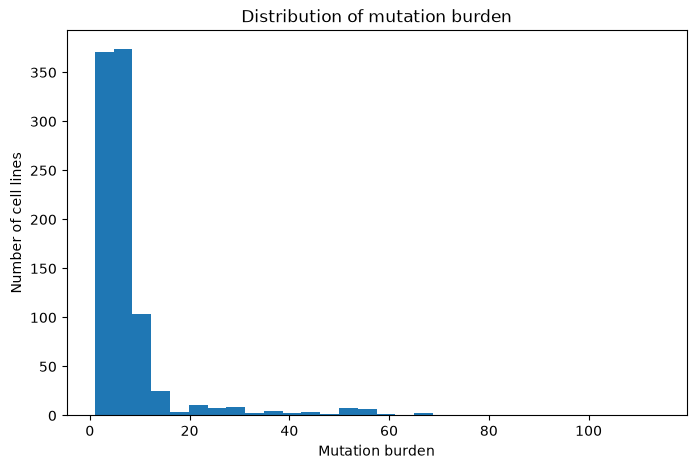

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(mutation_burden, bins=30)
plt.xlabel("Mutation burden")
plt.ylabel("Number of cell lines")
plt.title("Distribution of mutation burden")
plt.show()

### Incorporation of Mutation Burden into the Feature Matrix

Following validation, mutation burden was incorporated into the feature matrix as an additional predictor alongside the binary gene mutation features.

In [24]:
# Create a copy of the binary gene matrix
X_features = gene_matrix.copy()

# Add mutation burden
X_features["Mutation_Burden"] = mutation_burden

In [25]:
print(f"Feature matrix shape: {X_features.shape}")

print(f"Missing mutation burden values: {X_features['Mutation_Burden'].isna().sum()}")

Feature matrix shape: (948, 598)
Missing mutation burden values: 0
